<a href="https://colab.research.google.com/github/MegaDeadCowboy/jasper-burn-severity/blob/main/01_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Data: NBAC perimeter + Sentinel-2 pre/post composites

Outputs (to `data/`, git-ignored):
- `nbac_jasper_2024.gpkg`: Jasper fire perimeter from NBAC 2024
- `s2_pre_2023.tif`, `s2_post_2025.tif`: SCL-masked, offset-corrected median composites (B04, B08, B8A, B12) on a 20 m UTM 11N grid covering the perimeter + 2 km buffer

In [ ]:
![ -d /content/jasper-burn-severity ] || git clone https://github.com/MegaDeadCowboy/jasper-burn-severity.git /content/jasper-burn-severity
%cd /content/jasper-burn-severity
!pip install -q pystac-client planetary-computer stackstac rioxarray geopandas
import logging; logging.getLogger("rasterio._env").setLevel(logging.ERROR)

In [3]:
from pathlib import Path
import urllib.request, zipfile
import numpy as np
import geopandas as gpd
import xarray as xr
import rioxarray  # noqa: F401  (registers .rio)
import pystac_client, planetary_computer, stackstac
import matplotlib.pyplot as plt
from shapely.geometry import Point

DATA = Path("data"); DATA.mkdir(exist_ok=True)
UTM = 32611            # UTM 11N
RES = 20               # m; 20 m grid for all bands
BUFFER_M = 2000        # unburned margin kept for validation
PRE  = "2023-07-01/2023-08-31"
POST = "2025-07-01/2025-08-31"
BANDS = ["B04", "B08", "B8A", "B12", "SCL"]
JASPER_TOWN = Point(-118.0814, 52.8737)  # lon, lat; used only to pick the fire polygon

## 1. NBAC perimeter
Single-year 2024 file from the 1972–2025 release (CWFIS Datamart).

In [4]:
NBAC_URL = "https://cwfis.cfs.nrcan.gc.ca/downloads/nbac/NBAC_2024_20260513.zip"
nbac_zip = DATA / "NBAC_2024_20260513.zip"
if not nbac_zip.exists():
    urllib.request.urlretrieve(NBAC_URL, nbac_zip)
nbac_dir = DATA / "nbac_2024"
with zipfile.ZipFile(nbac_zip) as z:
    z.extractall(nbac_dir)
    print([n for n in z.namelist() if n.endswith((".shp", ".gdb/", ".gpkg"))])

['NBAC_2024_20260513.shp']


In [5]:
src = next(nbac_dir.rglob("*.shp"))   # if the release ships a .gdb instead, point gpd.read_file at it
nbac = gpd.read_file(src)
print(src.name, nbac.crs, len(nbac))
print(list(nbac.columns))

NBAC_2024_20260513.shp PROJCS["Canada_Lambert_Conformal_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-95],PARAMETER["standard_parallel_1",49],PARAMETER["standard_parallel_2",77],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]] 1970
['YEAR', 'NFIREID', 'BASRC', 'FIREMAPS', 'FIREMAPM', 'FIRECAUS', 'HS_SDATE', 'HS_EDATE', 'AG_SDATE', 'AG_EDATE', 'CAPDATE', 'POLY_HA', 'ADJ_HA', 'ADJ_FLAG', 'ADMIN_NAME', 'ADMIN_DIV', 'PRESCRIBED', 'VERSION', 'GID', 'geometry']


In [6]:
# Polygons within 40 km of the townsite; inspect before choosing
town = gpd.GeoSeries([JASPER_TOWN], crs=4326).to_crs(nbac.crs)
near = nbac[nbac.distance(town.iloc[0]) < 40_000]
cols = [c for c in ["YEAR","NFIREID","ADMIN_AREA","NATPARK","NATPARKS","AG_SDATE","HS_SDATE","POLY_HA","ADJ_HA","GID"] if c in near.columns]
near[cols].sort_values("POLY_HA", ascending=False)

,YEAR,NFIREID,AG_SDATE,HS_SDATE,POLY_HA,ADJ_HA,GID
456,2024.0,451.0,2024-07-22,2024-07-23,31644.597903,31644.597903,2024_451
725,2024.0,718.0,2024-07-18,2024-07-19,1.768331,1.768331,2024_718
726,2024.0,719.0,2024-07-18,NaT,0.247202,0.247202,2024_719


NFIREID: 451.0 | pieces: 1 | POLY_HA sum: 31644.6


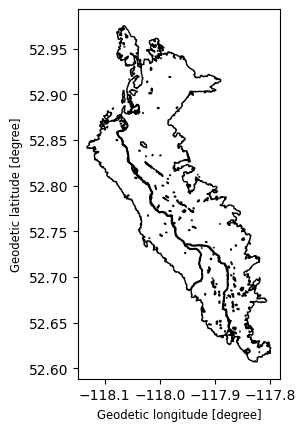

In [7]:
# Largest polygon's NFIREID = the Jasper fire; dissolve any park/province pieces sharing that ID
fire_id = near.sort_values("POLY_HA", ascending=False).iloc[0]["NFIREID"]
perim = nbac[nbac["NFIREID"] == fire_id].dissolve(by="NFIREID").reset_index()
print("NFIREID:", fire_id, "| pieces:", (nbac["NFIREID"] == fire_id).sum(),
      "| POLY_HA sum:", round(nbac.loc[nbac["NFIREID"] == fire_id, "POLY_HA"].sum(), 1))
perim.to_file(DATA / "nbac_jasper_2024.gpkg")
perim.to_crs(4326).plot(edgecolor="k", facecolor="none");

## 2. Sentinel-2 L2A search (Planetary Computer STAC)

In [8]:
perim_utm = perim.to_crs(UTM)
aoi_utm = perim_utm.buffer(BUFFER_M)
bounds = tuple(aoi_utm.total_bounds)          # in EPSG:32611
aoi_ll = aoi_utm.to_crs(4326).iloc[0]

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

def search(dt, max_cloud=60):
    items = catalog.search(collections=["sentinel-2-l2a"], intersects=aoi_ll,
                           datetime=dt, query={"eo:cloud_cover": {"lt": max_cloud}}).item_collection()
    print(dt, len(items), "items |", sorted({i.properties["s2:mgrs_tile"] for i in items}),
          "| baselines", sorted({i.properties.get("s2:processing_baseline") for i in items}))
    return items

items_pre, items_post = search(PRE), search(POST)

2023-07-01/2023-08-31 26 items | ['11UMU'] | baselines ['05.09', '05.10']
2025-07-01/2025-08-31 16 items | ['11UMU'] | baselines ['05.11']


## 3. Stack, mask, correct, composite
- **SCL keep-list** `{2, 4, 5, 6, 7}`: dark area, vegetation, bare soil, water, unclassified. Class 2 stays in because Sen2Cor often labels fresh char as "dark area". Clouds, shadow, cirrus, snow, and saturated/no-data pixels are dropped.
- **Offset:** baseline ≥ 04.00 → reflectance = (DN − 1000) / 10000; earlier → DN / 10000.

In [9]:
SCL_KEEP = [2, 4, 5, 6, 7]

def composite(items):
    da = stackstac.stack(items, assets=BANDS, epsg=UTM, resolution=RES, bounds=bounds,
                         dtype="float32", fill_value=np.float32(np.nan), rescale=False,
                         chunksize=1024)
    scl = da.sel(band="SCL")
    refl = da.sel(band=BANDS[:-1])
    baseline = da["s2:processing_baseline"].astype(float)   # stackstac carries item properties as coords
    offset = xr.where(baseline >= 4.0, 1000.0, 0.0).astype("float32")
    refl = ((refl - offset) / 10000.0).where(scl.isin(SCL_KEEP))
    refl = refl.clip(0, 1)  # negative after offset = sensor noise
    med = refl.median("time", skipna=True)
    n_valid = refl.sel(band="B8A").notnull().sum("time").rename("n_valid")
    return med, n_valid

pre, n_pre = composite(items_pre)
post, n_post = composite(items_post)
pre

<xarray.DataArray (band: 4, y: 2257, x: 1308)> Size: 47MB
dask.array<nanmedian, shape=(4, 2257, 1308), dtype=float32, chunksize=(1, 1233, 813), chunktype=numpy.ndarray>
Coordinates:
  * band                                     (band) <U3 48B 'B04' ... 'B12'
  * y                                        (y) float64 18kB 5.872e+06 ... 5...
  * x                                        (x) float64 10kB 4.217e+05 ... 4...
    s2:datatake_type                         <U8 32B 'INS-NOBS'
    s2:product_type                          <U7 28B 'S2MSI2A'
    instruments                              <U3 12B 'msi'
    s2:mgrs_tile                             <U5 20B '11UMU'
    s2:saturated_defective_pixel_percentage  float64 8B 0.0
    proj:code                                <U10 40B 'EPSG:32611'
    constellation                            <U10 40B 'Sentinel 2'
    proj:bbox                                object 8B {399960.0, 5900040.0, ...
    epsg                                     int64 8B 32611
Attributes:
    spec:        RasterSpec(epsg=32611, bounds=(421740, 5826880, 447900, 5872...
    crs:         epsg:32611
    transform:   | 20.00, 0.00, 421740.00|\n| 0.00,-20.00, 5872020.00|\n| 0.0...
    resolution:  20

In [ ]:
%%time
pre, n_pre = (x.compute() for x in (pre, n_pre))
post, n_post = (x.compute() for x in (post, n_post))

## 4. Checks

In [14]:
for name, n, img in [("pre", n_pre, pre), ("post", n_post, post)]:
    inside = n.astype("float32").rio.write_crs(UTM).rio.clip(perim_utm.geometry, drop=False)
    b12 = img.sel(band="B12")
    print(f"{name}: valid obs/pixel inside perimeter  min={int(np.nanmin(inside))}  "
          f"median={float(np.nanmedian(inside)):.0f} | zero-obs inside: {int((inside == 0).sum())} | "
          f"B12 >= 1.0 pixels: {int((b12 >= 1.0).sum())} of {int(b12.notnull().sum())}")

pre: valid obs/pixel inside perimeter  min=12  median=20 | zero-obs inside: 0 | B12 >= 1.0 pixels: 21 of 2952005
post: valid obs/pixel inside perimeter  min=8  median=14 | zero-obs inside: 0 | B12 >= 1.0 pixels: 34 of 2951263


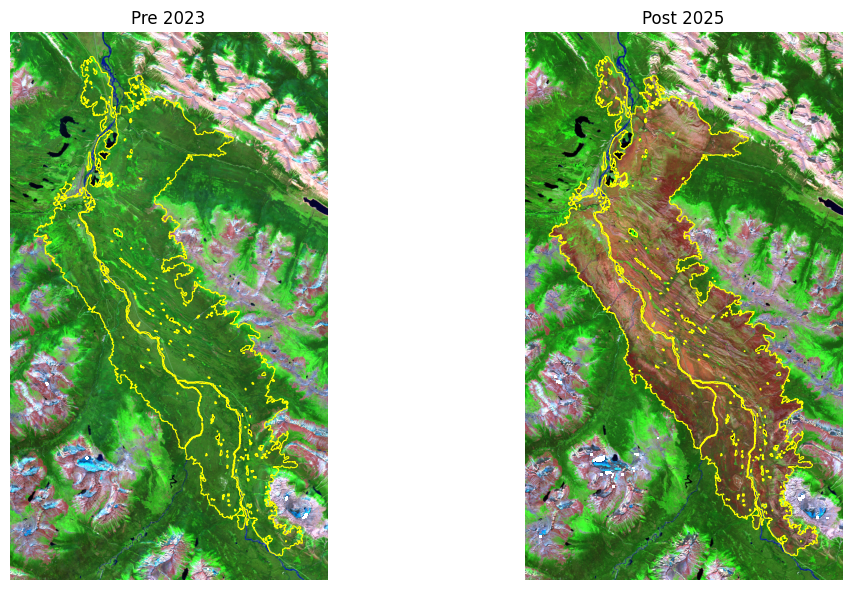

In [15]:
# Quick-look false colour (B12, B8A, B04); diagnostic only, not a final figure
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for ax, img, t in zip(axs, [pre, post], ["Pre 2023", "Post 2025"]):
    rgb = img.sel(band=["B12", "B8A", "B04"]).transpose("y", "x", "band")
    rgb = (rgb / rgb.quantile(0.98, dim=["y", "x"])).clip(0, 1)
    ax.imshow(rgb, extent=[bounds[0], bounds[2], bounds[1], bounds[3]])
    perim_utm.boundary.plot(ax=ax, color="yellow", lw=0.8)
    ax.set_title(t); ax.set_axis_off()
plt.tight_layout()

## 5. Save

In [16]:
def save(img, n, path):
    out = img.assign_coords(band=list(img.band.values)).rio.write_crs(UTM)
    out.attrs.update(scl_keep=str(SCL_KEEP), units="reflectance")
    out.rio.to_raster(path, compress="deflate")
    n.astype("uint16").rio.write_crs(UTM).rio.to_raster(path.with_name(path.stem + "_nvalid.tif"), compress="deflate")
    print("wrote", path)

save(pre, n_pre, DATA / "s2_pre_2023.tif")
save(post, n_post, DATA / "s2_post_2025.tif")

wrote data/s2_pre_2023.tif
wrote data/s2_post_2025.tif
